# Modelo 04: Gaussian Mixture Models (GMM)
En este entrenamiento utilizaremos Gaussian Mixture Models. Mientras que K-Means utiliza una métrica de distancia rígida, GMM utiliza el concepto de densidad probabilística, lo que le permite adaptarse a clústeres con formas elípticas y diferentes tamaños. Para determinar el número óptimo de componentes, utilizaremos dos criterios estadísticos fundamentales:
- BIC (Bayesian Information Criterion): Penaliza modelos más complejos para evitar el sobreajuste.
- AIC (Akaike Information Criterion): Similar al BIC, pero con una penalización menor por la complejidad.

[INFO] Calculando criterios de información...


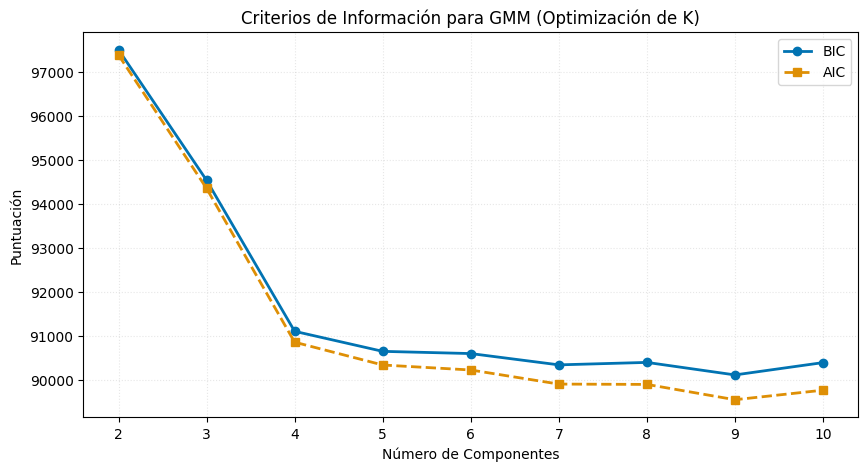

In [1]:
# 7.1. Búsqueda del número óptimo de componentes (BIC/AIC)

from sklearn.mixture import GaussianMixture
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# [INFO] Cargar los datos procesados con PCA
base_dir = '../../..'
df_pca = pd.read_csv(f'{base_dir}/data/processed/data_clustering_pca.csv')

n_components = range(2, 11)
bics = []
aics = []

print("[INFO] Calculando criterios de información...")

for n in n_components:
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(df_pca.iloc[:, :3])
    bics.append(gmm.bic(df_pca.iloc[:, :3]))
    aics.append(gmm.aic(df_pca.iloc[:, :3]))

# 7.2. Visualización de BIC y AIC

colors = sns.color_palette("colorblind")
plt.figure(figsize=(10, 5))
plt.plot(n_components, bics, label='BIC', marker='o', color=colors[0], 
         linewidth=2, linestyle='-')
plt.plot(n_components, aics, label='AIC', marker='s', color=colors[1], 
         linewidth=2, linestyle='--')
plt.title('Criterios de Información para GMM (Optimización de K)')
plt.xlabel('Número de Componentes')
plt.ylabel('Puntuación')
plt.legend()
plt.grid(True, alpha=0.3, linestyle=':')
plt.show()

### 7.3. Ajuste Final del Modelo GMM
Basándonos en la gráfica anterior, buscaremos el valor de componentes que minimice el BIC o donde la curva comience a aplanarse. 

Para mantener la comparabilidad con nuestro modelo K-Means, entrenaremos la versión definitiva con 4 componentes, permitiéndonos observar cómo la lógica probabilística redistribuye a los usuarios en comparación con la lógica de distancias de los centroides.

[INFO] Probabilidad media de asignación: 0.9477


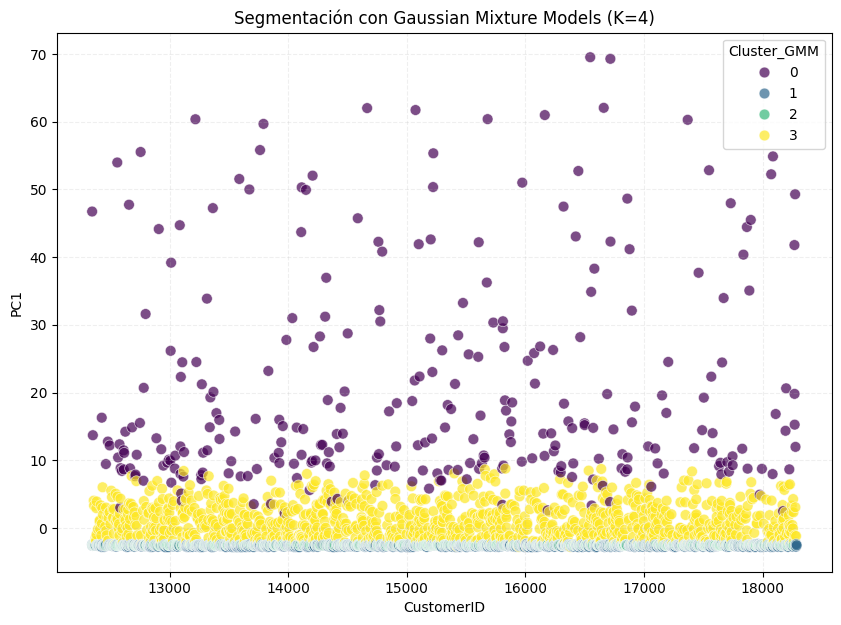

In [2]:
# 7.4. Entrenamiento y Visualización de Probabilidades

K_GMM = 4 

model_gmm = GaussianMixture(n_components=K_GMM, n_init=10, random_state=42)
df_pca['Cluster_GMM'] = model_gmm.fit_predict(df_pca.iloc[:, :3])

# [INFO] GMM nos permite ver la incertidumbre
probs = model_gmm.predict_proba(df_pca.iloc[:, :3])
df_pca['Max_Prob'] = probs.max(axis=1)

print(f"[INFO] Probabilidad media de asignación: {df_pca['Max_Prob'].mean():.4f}")

# 7.5. Visualización de Clústeres GMM

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=df_pca.columns[0], y=df_pca.columns[1], 
    hue='Cluster_GMM', 
    data=df_pca, 
    palette='viridis', 
    alpha=0.7,
    s=60,
    edgecolor='w',
    linewidth=0.5
)
plt.title(f'Segmentación con Gaussian Mixture Models (K={K_GMM})')
plt.grid(True, linestyle='--', alpha=0.2)
plt.show()

### 7.6. Perfilado y Comparativa de Negocio
Finalmente, contrastaremos los promedios RFM de este modelo con los obtenidos en los pasos previos. 

La gran ventaja de GMM es que, al ser un modelo basado en distribuciones, suele manejar mejor los grupos que se solapan en sus fronteras, lo que podría darnos una visión más matizada de la transición entre un cliente "VIP" y uno "Frecuente".

In [3]:
# [INFO] Carga de métricas reales para el perfilado
df_original = pd.read_csv(f'{base_dir}/data/interim/interim_ProyClustering/data_features_clean.csv')
df_original['Cluster'] = df_pca['Cluster_GMM'].values

perfil_gmm = df_original.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
perfil_gmm['Count'] = df_original.groupby('Cluster')['CustomerID'].count()

print("[INFO] Resumen de métricas por clúster (GMM):")
display(perfil_gmm.sort_values(by='Monetary', ascending=False).round(2))

[INFO] Resumen de métricas por clúster (GMM):


,Recency,Frequency,Monetary,Count
Cluster,,,,
3,61.97,5.37,1877.42,1077
0,91.18,4.93,1664.30,289
1,78.49,3.41,1101.43,1318
2,136.02,1.44,319.56,1459


### 7.7. Persistencia del Modelo: Gaussian Mixture Model
Dada la superioridad demostrada por el modelo probabilístico en la discriminación de perfiles de valor, el guardado de esta celda representa el paso más importante de nuestra fase de modelado. 
Al persistir el objeto Gaussian Mixture Model, estamos almacenando una estructura de datos capaz de calcular probabilidades de pertenencia para cualquier nuevo cliente que se incorpore a la plataforma en el futuro. 

In [9]:
import joblib

# [INFO] Guardar el modelo ganador y la base de datos final etiquetada
joblib.dump(model_gmm, f'{base_dir}/models/model_gmm_final.pkl')
df_pca.to_csv(f'{base_dir}/data/processed/data_clustering_gmm_final.csv', index=False)

print("[SUCCESS] Modelo GMM y resultados finales exportados correctamente.")

[SUCCESS] Modelo GMM y resultados finales exportados correctamente.
